In [4]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath(".."))

from src.legacy_cbms26.bags import generate_bags
from src.quantifiers.baselines import ACC

In [2]:
data = np.load("./data/processed/mitdb_preprocessed.npz")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
rec_train = data["rec_train"]
rec_test = data["rec_test"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positives:", np.sum(y_train==1))
print("Test positives:", np.sum(y_test==1))

Train shape: (77518, 360)
Test shape: (35129, 360)
Train positives: 46054
Test positives: 28998


In [3]:
bags_X_test, bags_prev_test = generate_bags(
  X_test, y_test,
  bag_size=500,
  n_bags=100,
  random_state=42
)

[INFO] Positive samples: 28998, Negative samples: 6131.


In [5]:
classifiers = {
  "Logistic Regression": LogisticRegression(max_iter=500),
  "Linear SVM": LinearSVC(),
  "RBF SVM": SVC(kernel="rbf", probability=True),
  "Random Forest": RandomForestClassifier(n_estimators=150),
  "Gradient Boosting": GradientBoostingClassifier(),
  "Ridge Classifier": RidgeClassifier(),
  "KNN": KNeighborsClassifier(n_neighbors=5),
}

In [6]:
def evaluate_cc_with_bags(clf, X_train, y_train, X_test, y_test,
                          bags_X_test, bags_prev_test):
  quantifier = ACC(classifier=clf)
  
  # Flatten
  X_train_f = X_train.reshape(len(X_train), -1)
  X_test_f = X_test.reshape(len(X_test), -1)

  quantifier.fit(X_train_f, y_train)
  # Instance-level metrics
  preds = quantifier.clf.predict(X_test_f)  
  accuracy = accuracy_score(y_test, preds)
  f1 = f1_score(y_test, preds)

  # CC Quantification
  maes = []
  for Xb, prev_true in zip(bags_X_test, bags_prev_test):
    Xb_f = Xb.reshape(len(Xb), -1)
    prev_pred = quantifier.predict(Xb_f)
    maes.append(abs(prev_pred - prev_true))

  mae_quant = np.mean(maes)

  return accuracy, f1, mae_quant

In [7]:
results = []

for name, model in classifiers.items():
  print(f"\n🔎 Avaliando {name}...")
  acc, f1, mae = evaluate_cc_with_bags(
    model, 
    X_train, y_train,
    X_test, y_test,
    bags_X_test, bags_prev_test
  )
  results.append([name, acc, f1, mae])


🔎 Avaliando Logistic Regression...

🔎 Avaliando Linear SVM...

🔎 Avaliando RBF SVM...

🔎 Avaliando Random Forest...

🔎 Avaliando Gradient Boosting...

🔎 Avaliando Ridge Classifier...

🔎 Avaliando KNN...


In [8]:
df = pd.DataFrame(results, columns=["model", "accuracy", "f1", "mae"])

df_sorted = df.sort_values("mae")
df_sorted

df_sorted.to_csv("../results/acc_ranking.csv", index=False)
print("Arquivo salvo em results/acc_ranking.csv")

Arquivo salvo em results/acc_ranking.csv


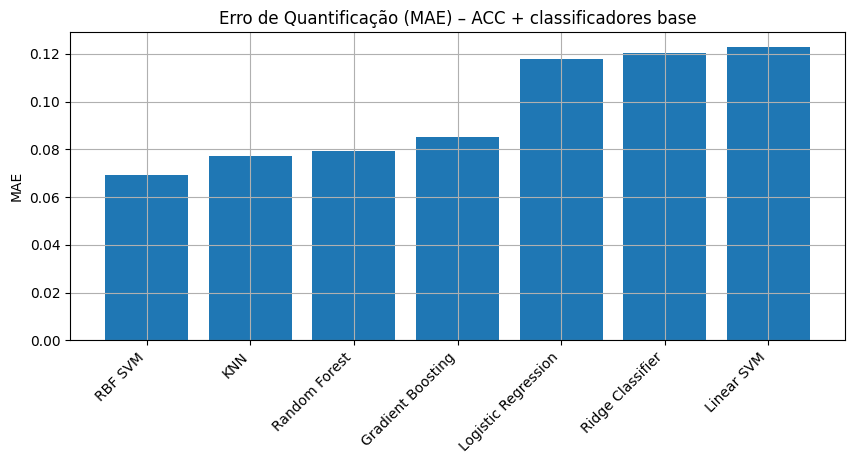

In [9]:
plt.figure(figsize=(10,4))
plt.bar(df_sorted["model"], df_sorted["mae"])
plt.xticks(rotation=45, ha="right")
plt.title("Erro de Quantificação (MAE) – ACC + classificadores base")
plt.ylabel("MAE")
plt.grid(True)
plt.show()